<center>
    

## <font color='maroon'>Classifying Stars Using Light Curves and a Shallow CNN Model</font>
        

</center>




### <font color='blue'>Introduction and Methodology</font>

In this project I use 25,000 light curves from stars of 5 different types as my data source, each of which contained between 10-1000 magnitude and time data points. From there, I used the time difference (dt) and magitude difference (dm) to construct a "dm-dt" image, binning every single pair of points into a category based on their time difference and magnitude differnece and constructing the image based on the frequency of points in each bin, normalized between 0 (meaning no dm-dt pairs in a certain bin) to 255 (meaning every single dm-dt pair in a given light curve was in a single bin). I then consturcted a combined dm-dt image for each class to visualize the difference in structure of each star type illuminated by using this strategy. 

I next moved into classification. I first split my images into training, validation, and test splits, opting for a 70-15-15 training-test-validation distribution, and I made sure to randomize the samples beforehand so that they werent organized by class, but also so the relationship between image and star type was conserved. Finally, I used a shallow CNN model to then test how discriminable these different classes are based on dm-dt images. In the future, I would like to test a classical nueral network on the light curves themselves, to see if the creation of these images gives valuable insight that makes classification easier. 

This project is inspired by and aims to replicate the paper Deep Learnt Classification of Light Curves, 2017, A Mahabal et All. : https://arxiv.org/pdf/1709.06257 

### Code

In [52]:
#Set this variable to be the path to the downloaded proj_light_curves_data folder
#If you put the data in the same directory as your notebook, this can be set to 'proj_light_curves_data/'
path_to_data = '/Users/jackc/downloads/proj_light_curves_data'

In [53]:
#Defines lists containing the IDs of different variable types in the database
#You can iterate over these lists to get all star IDs of a certain type
#Or you can pull a random entry from a list to get a random star for that class
cepheid = list(range(1,5001))
ecl = list(range(5001,10001))
rrly = list(range(10001,15001))
ds = list(range(15001,20001))
lpv = list(range(20001,25001))

#Defines a list containing the IDs of all stars in the database
#Iterate over this to iterate over every star
all_stars = list(range(1, 25001))

In [54]:
import os
import numpy as np

def glc(lc_id, return_extras=False, path_to_data=None):
    '''
    Gets the data for a given light curve. glc = "Get Light Curve"
    
    Parameters
    ----------
    lc_id : integer
        Light curve ID in the range [1,50000]

    return_extras: Boolean : default=False
        If True, the function will return all 3 items under "Returns"
        If False, the function will only return the light curve (lc)
        
    Returns
    -------
    lc : Numpy array with shape (3, len(lc))
        The light curve. lc[0] gives the time values, lc[1] gives the 
        magnitudes, and lc[2] gives the magnitude errors.
        
    lc_type : str
        The type of the light curve. Can be 'cepheid', 'ecl', 'rrly', 
        'ds' or 'lpv.' Returned only if return_extras is True.
        
    OGLE_id : str
        The OGLE ID of the light curve. Can be used to look up a star
        in the OGLE database. Returned only if return_extras is True.
    
    '''
    if path_to_data is None:
        print('Set path_to_data before using gcl!')
        
    lc = np.load(os.path.join(path_to_data, 'curves', str(lc_id) + '.npy'))
    with open(os.path.join(path_to_data, 'info.txt')) as file:
        lc_data = [line for line in file if line.startswith(str(lc_id))][0].split()
    lc_type, OGLE_id = lc_data[1:]
    if return_extras: return lc, lc_type, OGLE_id 
    return lc

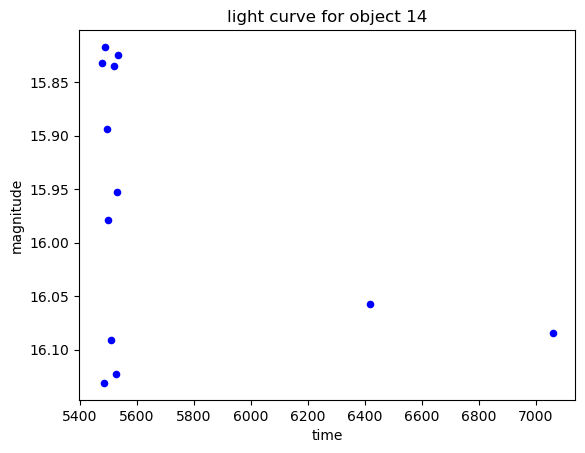

In [55]:
import matplotlib.pyplot as plt

#Specify a light curve here
lc_id = 14


#This code will graph the selected light curve
lc = glc(lc_id, path_to_data=path_to_data)
plt.scatter(lc[0], lc[1], s=20, c='b')
plt.xlabel('time')
plt.ylabel('magnitude')
plt.title('light curve for object ' + str(lc_id))
plt.gca().invert_yaxis()
plt.show()

In [56]:
images = []
labels = []
dm_bins = np.array([-8, -5, -3, -2.5, -2, -1.5, -1, -.5, -.3, -.2, -.1, 0, 0.1, 0.2, 0.3, 0.5, 1, 1.5, 2, 2.5, 3, 5, 8])
dt_bins = np.array([1/145, 2/145, 3/145, 4/145, 1/25, 2/25, 3/25, 1.5, 2.5, 3.5, 4.5, 5.5, 7, 10, 20, 30, 60, 90, 120, 240, 600, 960, 2000, 4000])
for i in range(1, 25000): 
    lc, lc_type, OGLE_id = glc(i, return_extras = True, path_to_data = path_to_data)
    times = lc[0]
    mags = lc[1] 
    dm = mags[:,None] - mags[None,:]
    dt = times[:,None] - times[None,:]
    #we want only unique pairs and no negative dt values: 
    dm = dm.ravel()
    dt = dt.ravel()
    mask = dt > 0 #we only want pairs such that the time difference between the pairs is larger than 0 (moving forweard in time on the light curve)
    dm = dm[mask]
    dt = dt[mask]
    H, xedges, yedges = np.histogram2d(dt, dm, bins = [dt_bins, dm_bins])
    #normalize histogram between 1 and 255
    n = len(times)
    p = n * (n - 1) // 2
    H_norm = (255 * H / p + 0.99999).astype(int)
    H_norm[H == 0] = 0

    #now we have to get a label as a star type!

    class_mapping = {
    "cepheid": 0,
    "ecl": 1,
    "rrly": 2,
    "ds": 3,
    "lpv":4 
        }
    star_type = class_mapping[lc_type]
    images.append(H_norm)
    labels.append(star_type)
    



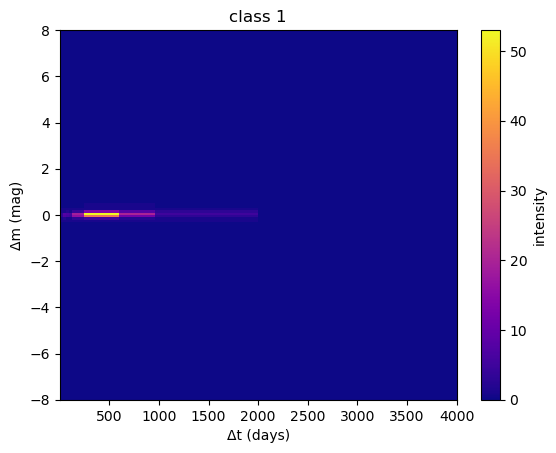

In [65]:
import matplotlib.pyplot as plt

plt.pcolormesh(dt_bins, dm_bins, images[8800].T, cmap="plasma")   # since dt bins are semi-log
plt.colorbar(label="intensity")
plt.xlabel("Δt (days)")
plt.ylabel("Δm (mag)")
plt.title(f"class {labels[8800]}")
plt.show()


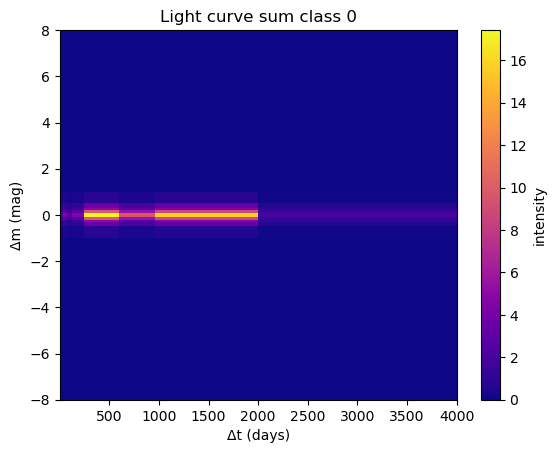

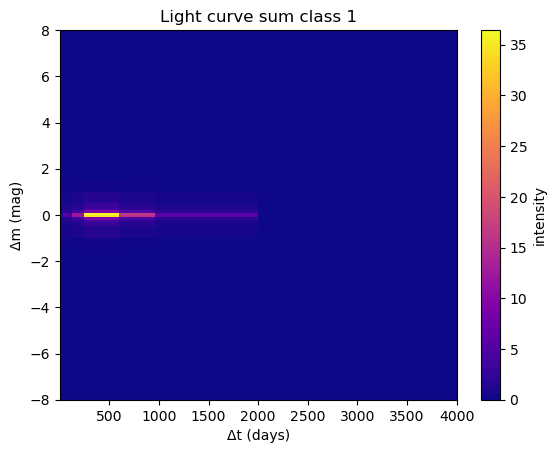

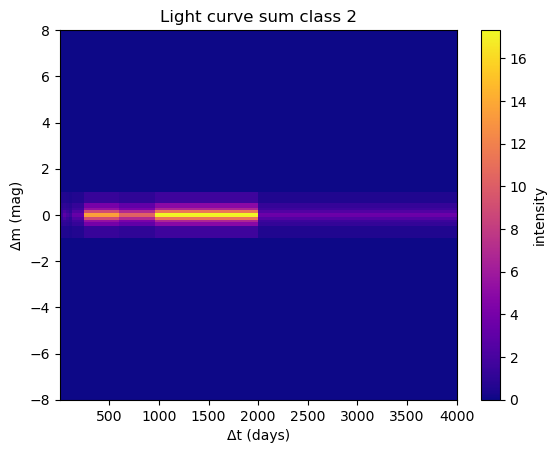

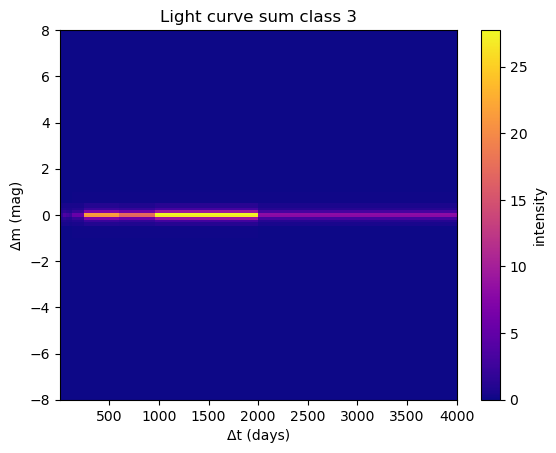

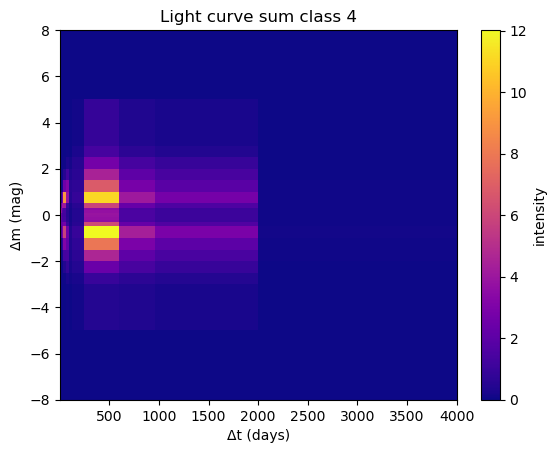

In [67]:
images = np.array(images)
labels = np.array(labels)

idx = np.random.permutation(len(labels))
images = images[idx]
labels = labels[idx]

indexes0 = np.where(labels == 0)[0]
array_0 = images[indexes0]
summed_array0 = np.sum(array_0, axis = 0)

normalized_array0 = summed_array0 /len(array_0)
plt.pcolormesh(dt_bins, dm_bins, normalized_array0.T, cmap="plasma")  # since dt bins are semi-log
plt.colorbar(label="intensity")
plt.xlabel("Δt (days)")
plt.ylabel("Δm (mag)")
plt.title(f"Light curve sum class 0")
plt.show()

indexes1 = np.where(labels == 1)[0]
array_1 = images[indexes1]
summed_array1 = np.sum(array_1, axis = 0)

normalized_array1 = summed_array1 /len(array_1)
plt.pcolormesh(dt_bins, dm_bins, normalized_array1.T, cmap="plasma")   # since dt bins are semi-log
plt.colorbar(label="intensity")
plt.xlabel("Δt (days)")
plt.ylabel("Δm (mag)")
plt.title(f"Light curve sum class 1")
plt.show()

indexes2 = np.where(labels == 2)[0]
array_2 = images[indexes2]
summed_array2 = np.sum(array_2, axis = 0)

normalized_array2 = summed_array2 /len(array_2)
plt.pcolormesh(dt_bins, dm_bins, normalized_array2.T, cmap="plasma")  # since dt bins are semi-log
plt.colorbar(label="intensity")
plt.xlabel("Δt (days)")
plt.ylabel("Δm (mag)")
plt.title(f"Light curve sum class 2")
plt.show()

indexes3 = np.where(labels == 3)[0]
array_3 = images[indexes3]
summed_array3 = np.sum(array_3, axis = 0)

normalized_array3 = summed_array3 /len(array_3)
plt.pcolormesh(dt_bins, dm_bins, normalized_array3.T, cmap="plasma")   # since dt bins are semi-log
plt.colorbar(label="intensity")
plt.xlabel("Δt (days)")
plt.ylabel("Δm (mag)")
plt.title(f"Light curve sum class 3")
plt.show()



indexes4 = np.where(labels == 4)[0]
array_4 = images[indexes4]
summed_array4 = np.sum(array_4, axis = 0)

normalized_array4 = summed_array4 /len(array_4)
plt.pcolormesh(dt_bins, dm_bins, normalized_array4.T, cmap="plasma")  # since dt bins are semi-log
plt.colorbar(label="intensity")
plt.xlabel("Δt (days)")
plt.ylabel("Δm (mag)")
plt.title(f"Light curve sum class 4")
plt.show()










In [69]:
import torch
import torch.nn as nn
import torch.nn.functional as F

X = torch.tensor(np.array(images), dtype=torch.float32)
y = torch.tensor(np.array(labels), dtype=torch.long)

# Add channel dimension (N, 1, H, W)
X = X.unsqueeze(1)

#datasets are already shuffled so we can just put them into sets
X_train = X[0:17500]

X_val = X[0:21500]

X_test = X[0:25000]

y_train = y[0:17500]

y_val = y[0:21500]

y_test = y[0:25000]


In [70]:

import torch
import torch.nn as nn

class LightCurveCNN(nn.Module):
    def __init__(self, n_classes, input_channels=1):
        super().__init__()
        
        self.main = nn.Sequential(
            # Conv block
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),  # 1x23x22 → 32x23x22
            nn.ReLU(),
            nn.MaxPool2d(2),   # ↓ halves dimensions → 32x11x11
            nn.Dropout(0.1),
            
            nn.Flatten(),      # → 32*11*11 = 3872 features
            nn.Linear(32*11*11, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes)  # final classifier
        )

    def forward(self, x):
        return self.main(x)

In [71]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LightCurveCNN(n_classes=len(set(labels)), input_channels=1)
model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3) #use simple preloaded loss and Adam optimizer

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=64)




In [72]:
n_epochs = 20

for epoch in range(n_epochs):
    #Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    #Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y_batch).sum().item()
            total += y_batch.size(0)

    val_loss /= total
    val_acc = correct / total

    print(f"Epoch {epoch+1}/{n_epochs} "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


Epoch 1/20 Train Loss: 0.3697, Acc: 0.8602 Val Loss: 0.1786, Acc: 0.9360
Epoch 2/20 Train Loss: 0.1994, Acc: 0.9318 Val Loss: 0.1587, Acc: 0.9406
Epoch 3/20 Train Loss: 0.1690, Acc: 0.9408 Val Loss: 0.1284, Acc: 0.9531
Epoch 4/20 Train Loss: 0.1487, Acc: 0.9479 Val Loss: 0.1157, Acc: 0.9586
Epoch 5/20 Train Loss: 0.1377, Acc: 0.9524 Val Loss: 0.1035, Acc: 0.9637
Epoch 6/20 Train Loss: 0.1261, Acc: 0.9566 Val Loss: 0.0956, Acc: 0.9657
Epoch 7/20 Train Loss: 0.1149, Acc: 0.9592 Val Loss: 0.0931, Acc: 0.9671
Epoch 8/20 Train Loss: 0.1112, Acc: 0.9625 Val Loss: 0.0828, Acc: 0.9706
Epoch 9/20 Train Loss: 0.1014, Acc: 0.9633 Val Loss: 0.0789, Acc: 0.9715
Epoch 10/20 Train Loss: 0.0986, Acc: 0.9651 Val Loss: 0.0818, Acc: 0.9716
Epoch 11/20 Train Loss: 0.0937, Acc: 0.9683 Val Loss: 0.0720, Acc: 0.9750
Epoch 12/20 Train Loss: 0.0900, Acc: 0.9683 Val Loss: 0.0656, Acc: 0.9764
Epoch 13/20 Train Loss: 0.0861, Acc: 0.9691 Val Loss: 0.0685, Acc: 0.9763
Epoch 14/20 Train Loss: 0.0842, Acc: 0.9706 Val

### <font color='blue'>Analysis</font>

The first thing that struck me about my results (and likely the reader of my project as well), was how succesfully my model was able to discriminate between classes, especially given that I only ran it for 20 epochs, it was a very shallow CNN, and that it used the same blueprint as the model in the paper did, which performed to about 83% after hundreds of epochs. Now, there are differences, both in the dataset used and my exact methodology, but this large a difference gave me great pause. A few possibilities entered my head: either my model is severely overfitting, there is some data leakage between the training, test, and validation sets, or maybe these specific star classes are more discriminable tha those used in the paper. I started by double checking the creation of my test training and validation sets, as well as the creation of the dm-dt images, tweaking how I set up each element of the input data, and I recieved high accuracies every time, in my eyes eliminating the possibility that it is the set-up of my dataset that is the problem. Then, in the following code, i tested the other two possibilities in two ways. First, I used a simple ML classifier, linear SVM, far less powerful and thus fa less prone to ovefitting than a CNN to see if my high accuacy could be replicated by a much simpler model. Secondly, I randomized the x training set again, this time not matching that randomization in the y set. My logic was that if my model truly was overffiting, it would continue to pick up patterns in the data and maintain relatively high (or at least non-random) accuracy even if the training sets were completely mismatched.

In [73]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y_batch).sum().item()
        total += y_batch.size(0)

print(f"Test Accuracy: {correct/total:.4f}")


Test Accuracy: 0.9808


In [74]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_params(model)
print(f"total params: {total:,}, trainable: {trainable:,}")

total params: 513,221, trainable: 513,221


In [75]:
#another sanity check of high accuracy: use a simple machine learning method to see ig I still get very high accuracy!
#looking for at least 88%-90% to make my results make sense

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

#flatten my input array X so that it can be used in a linear SVM model
n_samples = X.shape[0]
X_flat = X.reshape(n_samples, -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)

svm = SVC(kernel="linear", C=1.0, random_state=42)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"SVM test accuracy: {acc:.4f}")
print("\nDetailed report:\n")
print(classification_report(y_test, y_pred))


SVM test accuracy: 0.9380

Detailed report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1000
           1       0.97      0.97      0.97      1000
           2       0.90      0.89      0.89      1000
           3       0.91      0.89      0.90      1000
           4       1.00      1.00      1.00      1000

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



In [76]:
#my mode was extremely extremely good, maybe too good 
#so I decided to try it out with the labels swapped around randomly 
#to see if it is inventing connections between them 
#or if the classes just really are very seperable 

from torch.utils.data import TensorDataset, DataLoader, random_split

y_shuffled = y[torch.randperm(len(y))]


dataset = TensorDataset(X, y_shuffled)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

model = LightCurveCNN(n_classes=5)  # adjust n_classes
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
for epoch in range(20):  # keep short
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    acc = correct / total
    print(f"Epoch {epoch+1}, Val accuracy: {acc:.3f}")

Epoch 1, Val accuracy: 0.199
Epoch 2, Val accuracy: 0.200
Epoch 3, Val accuracy: 0.199
Epoch 4, Val accuracy: 0.201
Epoch 5, Val accuracy: 0.196
Epoch 6, Val accuracy: 0.200
Epoch 7, Val accuracy: 0.204
Epoch 8, Val accuracy: 0.200
Epoch 9, Val accuracy: 0.206
Epoch 10, Val accuracy: 0.196
Epoch 11, Val accuracy: 0.198
Epoch 12, Val accuracy: 0.208
Epoch 13, Val accuracy: 0.198
Epoch 14, Val accuracy: 0.204
Epoch 15, Val accuracy: 0.204
Epoch 16, Val accuracy: 0.198
Epoch 17, Val accuracy: 0.197
Epoch 18, Val accuracy: 0.194
Epoch 19, Val accuracy: 0.193
Epoch 20, Val accuracy: 0.207


### <font color='blue'>Conclusion</font>

Both of my tests seem to tell the same story. While not as high as the CNN's accuracy, linear SVM was able to reach its own absurdly hugh accuracy percentage of ~95%. Furthermore, when the X and Y sets were randomized, the CNN did no better than a guess, averaging about 20% accuracy, exactly what we should expect given there are 5 classes of stars. Both of these results indicated to me that my model was likely not overfitting (or at least to the absurd degree necessary to reach 98% precision). Instead, I can cautiously conclude that the star classes are either just extremely seperable, or something about creating dm-dt images creates patterns of information of a form that a shallow CNN model does extremely well with. 

Going forward, I would like to continue to explore this peculiarity further, using more datasets and applying more robust testing towards the possibility of overfitting. Furthermore, I would like to experiment with different and deeeper CNN architectures. 

Thank you for taking the time to read over my project, and let me know if you have any insights on any part of it, but especially my overfitting issue! 